In [1]:
import pandas as pd
from src.database import get_engine
# 3. Función de visualización común
def visualize_samples(df, target_col='target', features=None):
    # Asegurar que los individuos existen para evitar errores si el dataset es pequeño
    sample_0 = df[df[target_col] == 0].head(1)
    sample_1 = df[df[target_col] == 1].head(1)
    
    if sample_0.empty or sample_1.empty:
        return "No hay suficientes ejemplos de ambas clases (0 y 1) para visualizar."
    
    samples = pd.concat([sample_0, sample_1])
    return samples[features + [target_col]].T

print("Loaded visualize_samples")

Loaded visualize_samples


In [2]:
# 1. Obtener conexión y cargar datos
engine = get_engine()
query = "SELECT * FROM v_features_engineering"

print(f"Run QUERY : {query} ...")
df_db = pd.read_sql(query, engine)
print(f"Run QUERY Done!")



Run QUERY : SELECT * FROM v_features_engineering ...
Run QUERY Done!


In [9]:
# 2. Definir features de interés (las primeras 5 como ejemplo o una lista específica)
top_features = [col for col in df_db.columns if col not in ['target', 'id']][:10]

In [10]:
# Ejecutar visualización
print("Individuos desde la Base de Datos (v_features_engineering):")
visualize_samples(df_db, target_col='target', features=top_features)

Individuos desde la Base de Datos (v_features_engineering):


,5,11
sk_id_curr,100014,100112
name_contract_type,cash_loans,cash_loans
code_gender,f,m
flag_own_car,n,y
flag_own_realty,y,y
cnt_children,1,0
amt_income_total,112500.0,315000.0
amt_credit,652500.0,953460.0
amt_annuity,21177.0,64107.0
amt_goods_price,652500.0,900000.0


In [7]:
import pandas as pd
import os
from pathlib import Path

# 1. Definimos las raíces de las variables que nos interesan (de la DB)
raw_features_roots = [col for col in df_db.columns if col not in ['target', 'id']][:10]

# 2. Función para encontrar las columnas transformadas en el nuevo DataFrame
def get_transformed_columns(df, roots):
    matched_cols = []
    for root in roots:
        # Buscamos cualquier columna que contenga el nombre original
        matches = [col for col in df.columns if root in col]
        matched_cols.extend(matches)
    # Eliminamos duplicados y limitamos para que la visualización no explote
    return list(set(matched_cols))[:15]

In [8]:


# 1. Localizar la carpeta data/processed (independiente de si estás en / o en /notebooks)
# Si el notebook está en la raíz, Path('.') funciona. Si está en /notebooks, usamos Path('..')
base_dir = Path.cwd()
if base_dir.name == 'notebooks':
    path_processed = base_dir.parent / "data" / "processed"
else:
    path_processed = base_dir / "data" / "processed"


# 2. Bloque de carga y visualización desde CSV
try:
    X_train = pd.read_csv(path_processed / "X_train.csv")
    y_train = pd.read_csv(path_processed / "y_train.csv")

    df_processed = X_train.copy()
    target_name = y_train.columns[0]
    df_processed[target_name] = y_train.values

    # Identificamos las nuevas versiones de nuestras top_features
    current_top_features = get_transformed_columns(df_processed, raw_features_roots)

    print(f"Individuos desde {path_processed}:")
    print(f"Features detectadas tras transformación: {current_top_features}")
    
    display(visualize_samples(df_processed, target_col=target_name, features=current_top_features))

except FileNotFoundError as e:
    print(f"❌ Error: No se encontró el archivo. Detalles: {e}")
    print(f"Ruta buscada: {path_processed.absolute()}")

Individuos desde C:\Users\Public\IAE_DELL\pra_dell\m6_ocr\data\processed:
Features detectadas tras transformación: ['log__amt_credit', 'ohe__name_contract_type_revolving_loans', 'standard__cnt_children', 'log__amt_annuity', 'ohe__name_contract_type_cash_loans', 'ohe__code_gender_m', 'log__amt_income_total', 'log__amt_goods_price', 'ohe__code_gender_f']


,0,10
log__amt_credit,1.604828,0.768006
ohe__name_contract_type_revolving_loans,0.000000,0.000000
standard__cnt_children,-0.583133,-0.583133
log__amt_annuity,1.018131,0.203152
ohe__name_contract_type_cash_loans,1.000000,1.000000
ohe__code_gender_m,0.000000,1.000000
log__amt_income_total,-0.188149,-1.557081
log__amt_goods_price,1.568298,0.667751
ohe__code_gender_f,1.000000,0.000000
target,0.000000,1.000000


📊 Comparativa de Individuos (Valores tras Feature Engineering)


,Buen Pagador (Target=0),Riesgo Impago (Target=1)
standard__ext_source_2,0.720911,-0.438377
standard__ext_source_3,-0.867557,-2.496784
standard__days_id_publish,1.484551,1.286276
standard__days_last_phone_change,0.139114,0.445194
standard__days_registration,0.158525,0.052627
standard__days_birth,1.341658,1.341198
log__amt_annuity,-0.187529,1.815726
standard__days_employed,-0.453569,-0.463062
log__amt_income_total,-0.550846,1.534733
standard__ext_source_1,-1.362369,0.023047


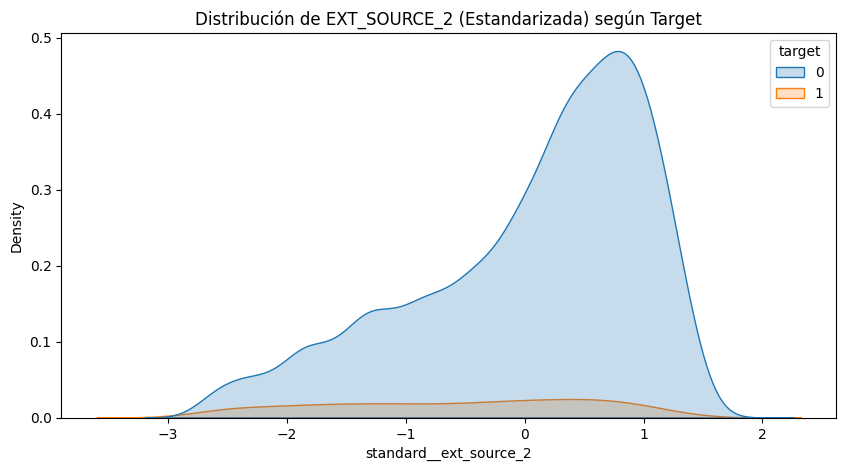

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Tu lista de variables ya transformadas (copiada de tu ranking)
top_features_transformed = [
    "standard__ext_source_2", "standard__ext_source_3", "standard__days_id_publish",
    "standard__days_last_phone_change", "standard__days_registration", "standard__days_birth",
    "log__amt_annuity", "standard__days_employed", "log__amt_income_total",
    "standard__ext_source_1", "log__amt_credit", "log__amt_goods_price"
]

# 2. Localizar carpeta
base_dir = Path.cwd()
path_processed = base_dir.parent / "data" / "processed" if base_dir.name == 'notebooks' else base_dir / "data" / "processed"

def visualize_comparison(df, target_col, features):
    """Muestra un individuo de cada clase para comparar valores transformados."""
    # Buscamos un ejemplo real de cada clase
    sample_0 = df[df[target_col] == 0].head(1)
    sample_1 = df[df[target_col] == 1].head(1)
    
    comparison = pd.concat([sample_0, sample_1])
    # Transponemos para facilitar la lectura vertical
    res = comparison[features + [target_col]].T
    res.columns = ['Buen Pagador (Target=0)', 'Riesgo Impago (Target=1)']
    return res

# 3. Ejecución principal
try:
    X_train = pd.read_csv(path_processed / "X_train.csv")
    y_train = pd.read_csv(path_processed / "y_train.csv")

    # Recomponer
    df_processed = X_train.copy()
    target_name = y_train.columns[0]
    df_processed[target_name] = y_train.values

    # Filtrar solo las que existen realmente en el CSV (evita errores si falta alguna)
    features_present = [f for f in top_features_transformed if f in df_processed.columns]

    print(f"📊 Comparativa de Individuos (Valores tras Feature Engineering)")
    display(visualize_comparison(df_processed, target_name, features_present))

    # --- Bonus: Visualización de Distribución ---
    # Como diría Geoffrey Hinton, entender la distribución es entender el modelo.
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df_processed, x="standard__ext_source_2", hue=target_name, fill=True)
    plt.title("Distribución de EXT_SOURCE_2 (Estandarizada) según Target")
    plt.show()

except FileNotFoundError:
    print(f"❌ Error: No se encuentran los CSV en {path_processed}. ¿Ejecutaste la Phase 2?")

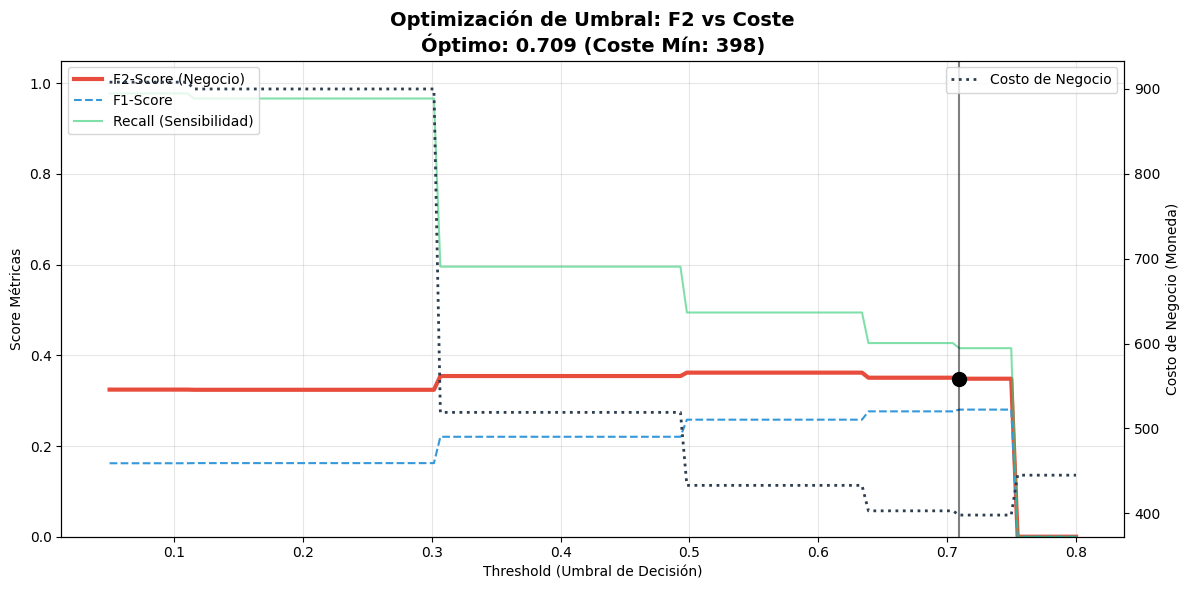

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de datos
df_curves = pd.read_csv('../reports/phase4_threshold_curve.csv')

def plot_threshold_curves(df):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Identificar el threshold óptimo (mínimo coste)
    idx_opt = df['cout_metier'].idxmin()
    best_threshold = df.loc[idx_opt, 'threshold']
    min_cost = df.loc[idx_opt, 'cout_metier']
    best_f2 = df.loc[idx_opt, 'f2']

    # --- Eje Izquierdo: Métricas (F1, F2, Recall) ---
    ax1.plot(df['threshold'], df['f2'], label='F2-Score (Negocio)', color='#e74c3c', linewidth=3)
    ax1.plot(df['threshold'], df['f1'], label='F1-Score', color='#3498db', linestyle='--')
    ax1.plot(df['threshold'], df['recall'], label='Recall (Sensibilidad)', color='#2ecc71', alpha=0.6)
    
    ax1.set_xlabel('Threshold (Umbral de Decisión)')
    ax1.set_ylabel('Score Métricas')
    ax1.set_ylim(0, 1.05)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # --- Eje Derecho: Coste Metier ---
    ax2 = ax1.twinx()
    ax2.plot(df['threshold'], df['cout_metier'], label='Costo de Negocio', color='#2c3e50', linewidth=2, linestyle=':')
    ax2.set_ylabel('Costo de Negocio (Moneda)')
    ax2.legend(loc='upper right')

    # --- Marcador del Punto Óptimo ---
    ax1.axvline(best_threshold, color='black', linestyle='-', alpha=0.5)
    ax1.scatter(best_threshold, best_f2, color='black', s=100, zorder=5)
    
    plt.title(f'Optimización de Umbral: F2 vs Coste\nÓptimo: {best_threshold:.3f} (Coste Mín: {min_cost})', 
              fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Ejecutar visualización
plot_threshold_curves(df_curves)